In [1]:
from typing import List,TypedDict
import re

import pypdf
from langchain_community.document_loaders import PyPDFLoader
from langchain_chroma import Chroma

from langchain_google_genai import ChatGoogleGenerativeAI,GoogleGenerativeAIEmbeddings

from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START,END
from pydantic import BaseModel
from dotenv import load_dotenv
load_dotenv()

C:\Users\gandh\AppData\Local\Temp\ipykernel_12096\2669185889.py:5: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.document_loaders import PyPDFLoader


True

In [2]:
docs = (
    PyPDFLoader("documents/oops.pdf").load()
)

In [3]:
chunks = RecursiveCharacterTextSplitter(chunk_size=500,chunk_overlap = 150).split_documents(docs)
for d in chunks:
    d.page_content = d.page_content.encode("utf-8","ignore").decode("utf-8","ignore")

In [4]:
len(chunks)

81

In [5]:
embedding = GoogleGenerativeAIEmbeddings(model="gemini-embedding-001")
vector_store = Chroma.from_documents(chunks,embedding)
retriever = vector_store.as_retriever(search_kwargs={"k":1})

In [6]:
llm = ChatGoogleGenerativeAI(model='gemini-2.5-flash-lite')

## State of the Graph

In [7]:
class State(TypedDict):
    question : str
    docs : List[Document]

    strips : List[str]
    kept_strips : List[str]
    refined_context : str

    answer : str

In [8]:
def retrieve(state: State) -> State:
    q = state['question']
    return {"docs":retriever.invoke(q)}

### Refine Node

In [9]:
# Decomposition 

def decompose_to_sentence(text: str) -> List[str]:

    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]


# Filter
class KeepOrDrop(BaseModel):
    keep : bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the questions\n"
            "Use only the sentence output json only"
        ),
        ("human","Question: {question}\n\n sentences: \n {sentence}"),
    ]
)


filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)


# Refine
def refine(state: State) -> State:

    q = state['question']

    context = "\n\n".join(d.page_content for d in state['docs']).strip()

    strips = decompose_to_sentence(context)

    kept : List[str] = []

    count  = 0
    for s in strips:
        if count > 1:
            break
        if filter_chain.invoke({"question":q,"sentence":s}).keep:
            kept.append(s)
        count += 1

    # Recompose
    refined_context = "\n\n".join(kept).strip()


    return {
        "strips": strips,
        "kept_strips":kept,
        "refined_context": refined_context,
    }

In [10]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are Helpful ML tutor. Answer only using the provided refined bullets.\n"
            "If the bullets are empty or insufficient say: I don't Know based on the provided book"
        ),
        ("human","Question: {question}\n\nRefined Context \n {refined_context}")
    ]
)

def generate(state: State):

    out = (answer_prompt | llm).invoke({"question": state['question'],"refined_context": state['refined_context']})

    return {"answer": out.content}

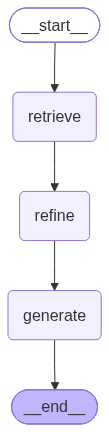

In [11]:
g = StateGraph(State)

g.add_node("retrieve",retrieve)
g.add_node("refine",refine)
g.add_node("generate",generate)

g.add_edge(START,"retrieve")
g.add_edge("retrieve","refine")
g.add_edge("refine","generate")
g.add_edge("generate",END)

app = g.compile()

app